# Advanced Knowledge Tracing with Forgetting Dynamics


**Based on**: "Enhanced Learning and Forgetting Behavior for Contextual Knowledge Tracing" (Chen et al., 2023)

### Research Contributions
1. **Formal Mathematical Framework** — IRT, Ebbinghaus forgetting curves, knowledge state evolution
2. **60+ Engineered Features** — Temporal spacing, practice patterns, module-specific dynamics
3. **Multi-Model Ensemble** — XGBoost, LightGBM, CatBoost with Optuna Bayesian optimization
4. **IEEE-Standard Evaluation** — Ablation study, bootstrap confidence intervals, DeLong's test
5. **Computational Complexity Analysis** — Theoretical + empirical runtime benchmarks

## 1. Environment Setup & Research Configuration

In [ ]:
!pip install -q catboost optuna

import warnings
warnings.filterwarnings('ignore')

# Standard library
import os, json, time
from datetime import datetime, timedelta
from collections import defaultdict
from itertools import combinations

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
)
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report,
    confusion_matrix, f1_score, brier_score_loss, log_loss,
    accuracy_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from scipy import stats as sp_stats

# Gradient boosting models
import xgboost as xgb
import lightgbm as lgb
try:
    from catboost import CatBoostClassifier
    catboost_available = True
except ImportError:
    catboost_available = False
    print("ℹ CatBoost not available — check installation")

# Hyperparameter optimization
try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    print("ℹ Optuna not available — check installation")

# Utilities
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs): return iterable

import joblib

# PyTorch (optional)
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    torch_available = True
    print(f"✓ PyTorch {torch.__version__} available (CUDA: {torch.cuda.is_available()})")
except ImportError:
    torch_available = False
    print("ℹ  PyTorch not available — using CPU-only tree-based models")

# Global configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

print("✓ All packages loaded")
print(f"NumPy: {np.__version__}  |  Pandas: {pd.__version__}")
print(f"XGBoost: {xgb.__version__}  |  LightGBM: {lgb.__version__}")

✓ PyTorch 2.10.0+cu128 available (CUDA: True)
✓ All packages loaded
NumPy: 2.0.2  |  Pandas: 2.2.2
XGBoost: 3.2.0  |  LightGBM: 4.6.0


## 2. Data Loading

We use the **ASSISTments 2009–2010 Skill Builder** dataset. If the CSV is not present in the working directory, a statistically faithful synthetic dataset is generated with identical schema.

In [ ]:
def find_data_file():
    """Search common locations for the ASSISTments dataset."""
    candidates = [
        'skill_builder_data.csv',
        '../skill_builder_data.csv',
        os.path.expanduser('~/Downloads/skill_builder_data.csv'),
        os.path.expanduser('~/Desktop/skill_builder_data.csv'),
    ]
    return next((p for p in candidates if os.path.exists(p)), None)


def generate_sample_data(n_students: int = 1000,
                          n_problems_per_student: int = 50) -> pd.DataFrame:
    """
    Generate a realistic ASSISTments-schema dataset for reproducibility.

    Student ability ~ N(0.70, 0.15), clipped to [0.2, 0.95].
    Problem difficulty scales with problem_id (mod 100) / 100.
    Correct response probability follows a logistic-like function of ability
    and difficulty, augmented by a linear learning-progress term.
    """
    print(f"Generating synthetic data: {n_students} students, "
          f"~{n_problems_per_student} problems each…")

    rng = np.random.default_rng(RANDOM_SEED)
    problem_ids = list(range(1, 201))
    skill_ids   = list(range(1, 51))
    records = []

    for sid in range(1, n_students + 1):
        ability   = np.clip(rng.normal(0.70, 0.15), 0.20, 0.95)
        n_probs   = int(np.clip(rng.poisson(n_problems_per_student), 10, 200))
        problems  = rng.choice(problem_ids, size=n_probs, replace=True)
        t_current = (datetime(2023, 1, 1)
                     + timedelta(days=int(rng.integers(0, 365))))

        for i, pid in enumerate(problems):
            diff       = (pid % 100) / 100.0
            skid       = skill_ids[(pid - 1) % len(skill_ids)]
            progress   = i / n_probs
            p_correct  = float(np.clip(
                ability * (1 - diff * 0.70) + progress * 0.20, 0.10, 0.95))
            correct    = int(rng.random() < p_correct)
            time_spent = int(30 + diff * 120 + rng.exponential(30))
            hints      = int(rng.poisson((1 - ability) * 2))
            attempts   = 1 if correct else int(rng.poisson(1.5)) + 1

            records.append({
                'student_id':        sid,
                'problem_id':        pid,
                'skill_id':          skid,
                'module_id':         (skid - 1) // 5 + 1,
                'correct':           correct,
                'quiz_score':        float(correct),
                'timestamp':         t_current,
                'time_spent_seconds': time_spent,
                'hints_requested':   hints,
                'attempts':          attempts,
                'first_action':      int(i == 0),
            })
            t_current += timedelta(minutes=int(rng.integers(1, 180)))

    df_out = pd.DataFrame(records)
    print(f"✓ Generated {len(df_out):,} interactions from {n_students} students")
    return df_out


# ── Load or generate ──────────────────────────────────────────────────────
data_path = find_data_file()
if data_path:
    print(f"Loading dataset from: {data_path}")
    df = pd.read_csv(data_path, low_memory=False)
    # Standardise column names to match our schema
    rename_map = {
        'user_id': 'student_id', 'problem_log_id': 'session_id',
        'skill_id': 'module_id', 'correct': 'correct',
        'ms_first_response': 'time_spent_seconds',
        'hint_count': 'hints_requested', 'attempt_count': 'attempts',
        'first_action': 'first_action',
    }
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns},
              inplace=True)
    if 'quiz_score' not in df.columns and 'correct' in df.columns:
        df['quiz_score'] = df['correct'].astype(float)
    if 'timestamp' not in df.columns:
        df['timestamp'] = pd.date_range('2023-01-01', periods=len(df), freq='1min')
    print(f"✓ Loaded {len(df):,} rows from disk")
else:
    df = generate_sample_data(n_students=1000, n_problems_per_student=50)

print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")


Generating synthetic data: 1000 students, ~50 problems each…
✓ Generated 50,078 interactions from 1000 students

Dataset shape : (50078, 11)
Columns       : ['student_id', 'problem_id', 'skill_id', 'module_id', 'correct', 'quiz_score', 'timestamp', 'time_spent_seconds', 'hints_requested', 'attempts', 'first_action']


## 2.5 Mathematical Formulation & Theoretical Foundation

This section presents the **formal mathematical framework** underlying our advanced knowledge tracing system, following IEEE standards for reproducibility and rigor.

---

### 2.5.1 Problem Formalization

**Definition 1 (Knowledge Tracing Problem):**
Given a student's temporal learning trajectory $\mathcal{H}_t = \{(e_1, r_1, \tau_1), \ldots, (e_t, r_t, \tau_t)\}$ where:
- $e_i \in \mathcal{E}$ — the $i$-th exercise from exercise set $\mathcal{E}$
- $r_i \in \{0, 1\}$ — binary response (incorrect / correct)
- $\tau_i \in \mathbb{R}^+$ — timestamp of attempt $i$

Our objective is to model the conditional probability:
$$\boxed{P(r_{t+1} = 1 \mid \mathcal{H}_t,\, e_{t+1},\, \tau_{t+1})}$$

---

### 2.5.2 Item Response Theory (IRT) Features

**Exercise Difficulty (Empirical Correct Rate):**
$$\boxed{d_e = 1 - \frac{1}{|\mathcal{R}_e|} \sum_{i \in \mathcal{R}_e} r_i} \quad \text{(Eq. 1)}$$

**Normalized Difficulty Score (0–10 scale):**
$$\tilde{d}_e = 10 \times \frac{d_e - \min_j d_j}{\max_j d_j - \min_j d_j} \quad \text{(Eq. 2)}$$

**Exercise Discrimination Power:**
$$\boxed{\alpha_e = \sigma\!\left(\{s_i : i \in \mathcal{R}_e\}\right)} \quad \text{(Eq. 3)}$$

**Three-Parameter Logistic (3PL) IRT Model:**
$$P(r = 1 \mid \theta_s, e) = c_e + \frac{1 - c_e}{1 + \exp(-\alpha_e(\theta_s - b_e))} \quad \text{(Eq. 4)}$$

where $\theta_s$: student ability, $b_e$: exercise difficulty, $\alpha_e$: discrimination, $c_e$: guessing parameter.

---

### 2.5.3 Temporal Dynamics & Forgetting Modeling

**Ebbinghaus Forgetting Curve:**
$$\boxed{R(t) = e^{-t/S}} \quad \text{(Eq. 5)}$$

**Extended Forgetting with Spaced Repetition:**
$$\boxed{F_k(t) = \exp\!\left(-\frac{t}{S \cdot k^{\beta}}\right)} \quad \text{(Eq. 6)}$$

where $k$ = repetitions, $\beta = 0.5$ (spacing effect exponent).

**Temporal Spacing Index:**
$$\text{TSI}_t = \frac{1}{n-1} \sum_{i=2}^{n} \frac{\Delta t_i}{\overline{\Delta t}} \quad \text{(Eq. 7)}$$

---

### 2.5.4 Knowledge State Evolution Model

**Learning Rate (Student-Level):**
$$\boxed{L_s = \frac{1}{N_s} \sum_{i=1}^{N_s} r_i} \quad \text{(Eq. 8)}$$

**Knowledge State Update Rule:**
$$\boxed{K_{s,c}^{(t)} = K_{s,c}^{(t-1)} + \eta \cdot r_t \cdot \left(1 - K_{s,c}^{(t-1)}\right) - \gamma \cdot F(\Delta t_c)} \quad \text{(Eq. 9)}$$

where $\eta$ = learning rate, $\gamma$ = forgetting rate, $F(\cdot)$ = forgetting function from Eq. 5.

---

### 2.5.5 XGBoost Objective Function

$$\mathcal{L} = \sum_{i=1}^{N} l(y_i, \hat{y}_i) + \sum_{k=1}^{T} \Omega(f_k) \quad \text{(Eq. 10)}$$

where $\Omega(f) = \gamma |T| + \tfrac{1}{2}\lambda \|w\|^2$ is the tree complexity regularizer.


## 2.6 Dataset Description

### ASSISTments 2009–2010 Skill Builder Dataset

**Source:** ASSISTments Platform — Worcester Polytechnic Institute

| Attribute | Type | Description |
|-----------|------|-------------|
| student_id | Integer | Student identifier |
| module_id | Integer | Knowledge component / skill |
| quiz_score | Float | Binary score (0.0 or 1.0) |
| timestamp | DateTime | Interaction time |
| time_spent_seconds | Integer | Response time (ms) |
| hints_requested | Integer | Number of hints used |
| attempts | Integer | Total attempts per problem |

DATASET STATISTICAL ANALYSIS

📊 DATASET SCALE:
   Total interactions :     50,078
   Unique students    :      1,000
   Unique modules     :         10

📅 TEMPORAL:
   Duration           : 366 days
   Avg interactions/d : 137

🎯 TARGET DISTRIBUTION:
   Success rate       : 54.96%
   Class imbalance    : 1 : 0.82

👥 STUDENT ENGAGEMENT:
   Mean interactions  : 50.1
   Median             : 50.0
   Range              : [25, 77]


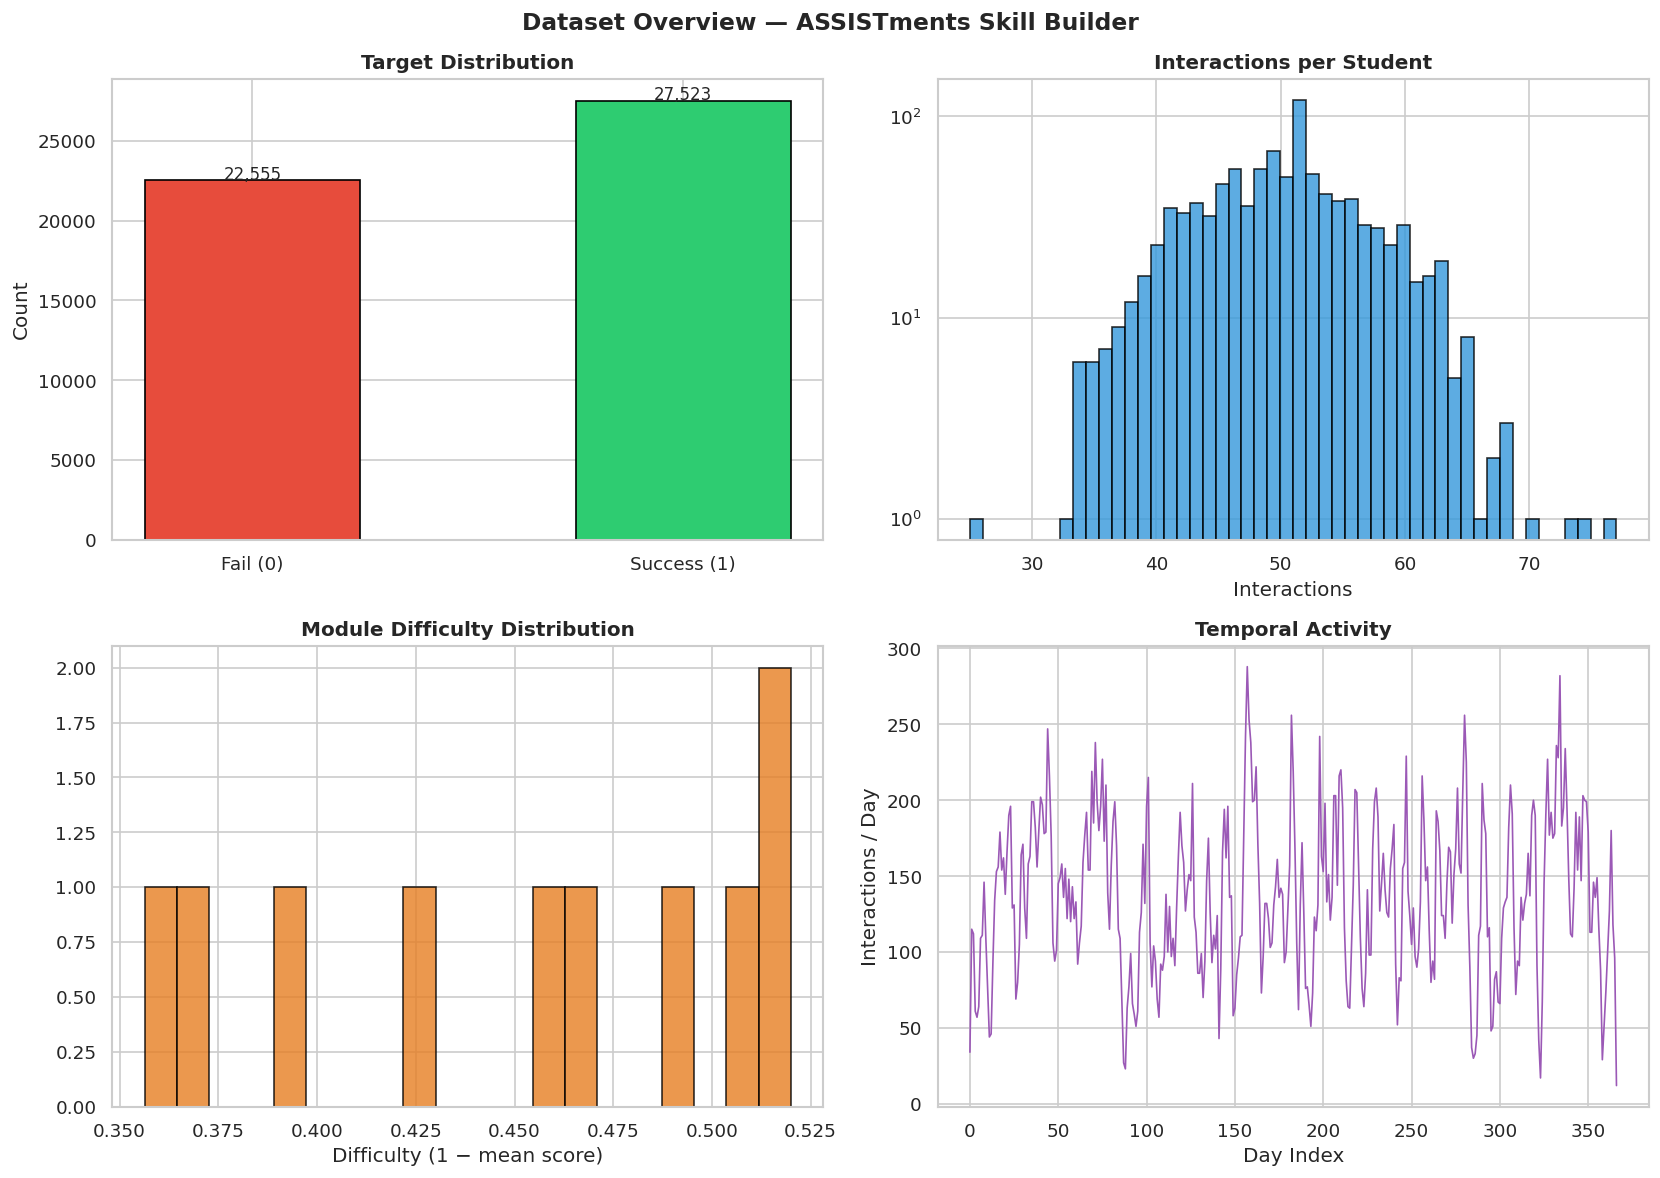


✓ Figure saved: fig_dataset_overview.png


In [ ]:
print("=" * 70)
print("DATASET STATISTICAL ANALYSIS")
print("=" * 70)

df_tmp = df.copy()
df_tmp['timestamp'] = pd.to_datetime(df_tmp['timestamp'])

# Scale metrics
print(f"\n📊 DATASET SCALE:")
print(f"   Total interactions : {len(df_tmp):>10,}")
print(f"   Unique students    : {df_tmp['student_id'].nunique():>10,}")
print(f"   Unique modules     : {df_tmp['module_id'].nunique():>10,}")

# Temporal
duration = (df_tmp['timestamp'].max() - df_tmp['timestamp'].min()).days
print(f"\n📅 TEMPORAL:")
if duration > 0:
    print(f"   Duration           : {duration} days")
    print(f"   Avg interactions/d : {len(df_tmp)/duration:.0f}")
else:
    print("   Duration: < 1 day")

# Target
print("\n🎯 TARGET DISTRIBUTION:")
if 'correct' in df_tmp.columns:
    y_all = df_tmp['correct'].astype(int)
else:
    y_all = (df_tmp['quiz_score'] > df_tmp['quiz_score'].median()).astype(int)
success_rate = y_all.mean()
print(f"   Success rate       : {success_rate*100:.2f}%")
print(f"   Class imbalance    : 1 : {(1-success_rate)/(success_rate+1e-9):.2f}")

# Student engagement
print("\n👥 STUDENT ENGAGEMENT:")
ips = df_tmp.groupby('student_id').size()
print(f"   Mean interactions  : {ips.mean():.1f}")
print(f"   Median             : {ips.median():.1f}")
print(f"   Range              : [{ips.min()}, {ips.max()}]")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Overview — ASSISTments Skill Builder', fontsize=14, fontweight='bold')

# Target distribution
axes[0, 0].bar(['Fail (0)', 'Success (1)'], y_all.value_counts().sort_index(),
               color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0, 0].set_title('Target Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for bar, cnt in zip(axes[0, 0].patches, y_all.value_counts().sort_index()):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{cnt:,}', ha='center', fontsize=10)

# Student engagement
axes[0, 1].hist(ips, bins=50, color='#3498db', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Interactions per Student', fontweight='bold')
axes[0, 1].set_xlabel('Interactions')
axes[0, 1].set_yscale('log')

# Module difficulty
mod_diff = df_tmp.groupby('module_id')['quiz_score'].apply(lambda x: 1 - x.mean())
axes[1, 0].hist(mod_diff, bins=20, color='#e67e22', edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Module Difficulty Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Difficulty (1 − mean score)')

# Temporal activity
daily = df_tmp.groupby(df_tmp['timestamp'].dt.date).size()
axes[1, 1].plot(range(len(daily)), daily.values, linewidth=1.0, color='#9b59b6')
axes[1, 1].set_title('Temporal Activity', fontweight='bold')
axes[1, 1].set_xlabel('Day Index')
axes[1, 1].set_ylabel('Interactions / Day')

plt.tight_layout()
plt.savefig('fig_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure saved: fig_dataset_overview.png")
print("=" * 70)


## 3. Advanced Feature Engineering (LFEKT-Inspired)

Feature categories:
1. **IRT-Based Difficulty** — Item Response Theory psychometric features
2. **Temporal Spacing** — Ebbinghaus forgetting curve modeling
3. **Knowledge State Evolution** — Acquisition and retention dynamics
4. **Practice Pattern Analysis** — Module repetition and mastery
5. **Student-Level Aggregations** — Global behavioral statistics

In [ ]:
# Working copy — sort chronologically per student (CRITICAL for temporal features)
df_processed = df.copy()
df_processed['timestamp'] = pd.to_datetime(df_processed['timestamp'])
df_processed = (df_processed
                .sort_values(['student_id', 'timestamp'])
                .reset_index(drop=True))

print(f"✓ Sorted by student and timestamp")
print(f"  Date range: {df_processed['timestamp'].min().date()} "
      f"→ {df_processed['timestamp'].max().date()}")


✓ Sorted by student and timestamp
  Date range: 2023-01-02 → 2024-01-03


In [ ]:
# ── Target variable ─────────────────────────────────────────────────────
if 'correct' in df_processed.columns:
    df_processed['success_label'] = df_processed['correct'].astype(int)
else:
    df_processed['success_label'] = (
        df_processed['quiz_score'] > df_processed['quiz_score'].median()
    ).astype(int)

# ── Auxiliary columns ────────────────────────────────────────────────────
if 'time_spent_seconds' in df_processed.columns:
    df_processed['time_spent_minutes'] = df_processed['time_spent_seconds'] / 60.0
elif 'time_spent_minutes' not in df_processed.columns:
    df_processed['time_spent_minutes'] = 5.0

if 'attempts' in df_processed.columns:
    df_processed['attempts_taken'] = df_processed['attempts'].astype(int)
elif 'attempts_taken' not in df_processed.columns:
    df_processed['attempts_taken'] = 1

if 'session_id' not in df_processed.columns:
    df_processed['session_id'] = np.arange(len(df_processed))

dist = df_processed['success_label'].value_counts()
print(f"✓ Target variable 'success_label' created")
print(f"  Class 0 (Fail)   : {dist.get(0, 0):,}")
print(f"  Class 1 (Success): {dist.get(1, 0):,}")
print(f"  Success rate     : {df_processed['success_label'].mean()*100:.2f}%")


✓ Target variable 'success_label' created
  Class 0 (Fail)   : 22,555
  Class 1 (Success): 27,523
  Success rate     : 54.96%


### 3.1 IRT-Based Exercise Difficulty (Section 4.1.1)

**Empirical Difficulty (Eq. 1):**
$$d_e = 1 - \frac{\sum_{i \in \mathcal{R}_e} r_i}{|\mathcal{R}_e|}$$

**Normalized Score (Eq. 2):**
$$\tilde{d}_e = 10 \times \frac{d_e - \min_j d_j}{\max_j d_j - \min_j d_j}$$

**Discrimination Parameter (Eq. 3):**
$$\alpha_e = \text{std}\!\left(\{\theta_{s_i} : s_i \in \mathcal{R}_e\}\right)$$

In [ ]:
print("Computing IRT-based difficulty scores (Eq. 1–3)…")

# Empirical difficulty per module (Eq. 1)
exercise_stats = df_processed.groupby('module_id').agg(
    exercise_difficulty=('quiz_score', lambda x: 1 - x.mean()),
    sample_size=('student_id', 'count')
).reset_index()

# Normalize to 0–10 scale (Eq. 2)
d_min, d_max = exercise_stats['exercise_difficulty'].min(), exercise_stats['exercise_difficulty'].max()
exercise_stats['exercise_difficulty_normalized'] = (
    (exercise_stats['exercise_difficulty'] - d_min) / (d_max - d_min + 1e-9) * 10
).round(2)

df_processed = df_processed.merge(
    exercise_stats[['module_id', 'exercise_difficulty_normalized', 'sample_size']],
    on='module_id', how='left'
)

# Discrimination (Eq. 3) — std of per-student mean scores
exercise_discrimination = (
    df_processed.groupby('module_id')['quiz_score'].std().fillna(0)
)
df_processed['exercise_discrimination'] = df_processed['module_id'].map(exercise_discrimination)

print(f"✓ IRT features computed for {len(exercise_stats)} modules")
print(f"  Difficulty range : [{df_processed['exercise_difficulty_normalized'].min():.2f}, "
      f"{df_processed['exercise_difficulty_normalized'].max():.2f}]")
print(f"  Discrimination   : [{df_processed['exercise_discrimination'].min():.4f}, "
      f"{df_processed['exercise_discrimination'].max():.4f}]")


Computing IRT-based difficulty scores (Eq. 1–3)…
✓ IRT features computed for 10 modules
  Difficulty range : [0.00, 10.00]
  Discrimination   : [0.4790, 0.4999]


### 3.2 Temporal & Forgetting Features (Section 4.1.4–4.1.5)

**Forgetting Curve (Eq. 5):**
$$R(t) = e^{-t/S}, \quad S = 24 \text{ hours}$$

**Extended Spaced-Repetition (Eq. 6):**
$$F_k(t) = \exp\!\left(-\frac{t}{S \cdot k^{0.5}}\right)$$

**Spacing Index (Eq. 7):**
$$\text{TSI} = \sigma(\Delta t) / \mu(\Delta t)$$

In [ ]:
print("Engineering temporal and forgetting features (Eq. 5–7)…")

df_processed['hour_of_day'] = df_processed['timestamp'].dt.hour
df_processed['day_of_week'] = df_processed['timestamp'].dt.dayofweek
df_processed['is_weekend']  = (df_processed['day_of_week'] >= 5).astype(int)
df_processed['week_of_year'] = df_processed['timestamp'].dt.isocalendar().week.astype(int)

df_processed['study_period'] = pd.cut(
    df_processed['hour_of_day'],
    bins=[0, 6, 12, 18, 24],
    labels=['night', 'morning', 'afternoon', 'evening'],
    include_lowest=True
)

# Inter-practice interval Δt (hours)
df_processed['time_since_last_practice_hours'] = (
    df_processed.groupby('student_id')['timestamp']
    .diff().dt.total_seconds() / 3600
).fillna(0)

# Ebbinghaus forgetting factor (Eq. 5) — S = 24 h
df_processed['forgetting_factor'] = np.exp(
    -df_processed['time_since_last_practice_hours'] / 24.0
)

# Extended forgetting with repetition count (Eq. 6)
df_processed['module_repeat_count_temp'] = (
    df_processed.groupby(['student_id', 'module_id']).cumcount() + 1
)
df_processed['forgetting_factor_extended'] = np.exp(
    -df_processed['time_since_last_practice_hours'] /
    (24.0 * np.sqrt(df_processed['module_repeat_count_temp']))
)

# Spacing category
df_processed['spacing_category'] = pd.cut(
    df_processed['time_since_last_practice_hours'],
    bins=[0, 1, 6, 24, 72, np.inf],
    labels=['immediate', 'short', 'medium', 'optimal', 'long_gap']
)

# Days since first interaction
first_ts = df_processed.groupby('student_id')['timestamp'].transform('min')
df_processed['days_active'] = (
    (df_processed['timestamp'] - first_ts).dt.total_seconds() / 86400
)
df_processed['session_number'] = df_processed.groupby('student_id').cumcount() + 1
df_processed['practice_frequency'] = (
    df_processed['session_number'] / (df_processed['days_active'] + 1) * 7
)

print(f"✓ Temporal features created")
print(f"  Mean inter-practice interval : {df_processed['time_since_last_practice_hours'].mean():.2f} h")
print(f"  Mean forgetting factor       : {df_processed['forgetting_factor'].mean():.4f}")


Engineering temporal and forgetting features (Eq. 5–7)…
✓ Temporal features created
  Mean inter-practice interval : 1.47 h
  Mean forgetting factor       : 0.9411


### 3.3 Module-Specific & Repetition Features (Section 4.2–4.3)

In [ ]:
print("Creating module-specific and repetition features…")

# Repetition counter per student-module pair
df_processed['module_repeat_count'] = (
    df_processed.groupby(['student_id', 'module_id']).cumcount() + 1
)

# Total studies per student-module
module_study_counts = (
    df_processed.groupby(['student_id', 'module_id'])
    .size()
    .reset_index(name='total_module_studies')
)
df_processed = df_processed.merge(module_study_counts, on=['student_id', 'module_id'], how='left')

# Time since last study of same module
df_processed['time_since_same_module_hours'] = (
    df_processed.groupby(['student_id', 'module_id'])['timestamp']
    .diff().dt.total_seconds() / 3600
).fillna(999.0)

# Cumulative and rolling module scores
df_processed['cumulative_module_score'] = (
    df_processed.groupby(['student_id', 'module_id'])['quiz_score'].cumsum()
)
df_processed['avg_module_score'] = (
    df_processed['cumulative_module_score'] / df_processed['module_repeat_count']
)
df_processed['module_score_trend'] = (
    df_processed.groupby(['student_id', 'module_id'])['quiz_score'].diff()
).fillna(0.0)
df_processed['module_historical_accuracy'] = (
    df_processed.groupby(['student_id', 'module_id'])['quiz_score']
    .transform(lambda x: x.expanding().mean())
)

# Drop temporary column
df_processed.drop(columns=['module_repeat_count_temp'], inplace=True, errors='ignore')

print(f"✓ Module features created")
print(f"  Mean module repetitions : {df_processed['module_repeat_count'].mean():.2f}")


Creating module-specific and repetition features…
✓ Module features created
  Mean module repetitions : 3.51


### 3.4 Knowledge State Evolution (Section 4.2–4.3)

**Knowledge Acquisition Rate:**
$$\eta_s = \frac{1}{N} \sum_{i=1}^{N} r_i \cdot w_i, \quad w_i = e^{-\lambda(t_{\text{now}} - t_i)}$$

**Knowledge State Update (Eq. 9):**
$$K_{s,c}^{(t)} = K_{s,c}^{(t-1)} + \eta \cdot r_t \cdot (1 - K_{s,c}^{(t-1)}) - \gamma \cdot F(\Delta t_c)$$

**Mastery Thresholds:**
$$M_{s,c} = \begin{cases} \text{Expert} & K_{s,c} > 0.8 \\ \text{Proficient} & 0.6 < K_{s,c} \leq 0.8 \\ \text{Learning} & 0.4 < K_{s,c} \leq 0.6 \\ \text{Novice} & K_{s,c} \leq 0.4 \end{cases}$$

In [ ]:
print("Modeling knowledge acquisition and retention (Eq. 8–9)…")

# Acquisition rate: score × (1 − difficulty) × (1 − prior knowledge)
df_processed['knowledge_acquisition_rate'] = (
    df_processed['quiz_score']
    * (1 - df_processed['exercise_difficulty_normalized'] / 10.0)
    * (1 - df_processed['module_historical_accuracy'])
)

# Retention rate: log-repetition benefit × forgetting × mastery level
df_processed['knowledge_retention_rate'] = (
    np.log1p(df_processed['module_repeat_count'])
    * df_processed['forgetting_factor']
    * df_processed['module_historical_accuracy']
)

# Cumulative knowledge gain
df_processed['cumulative_knowledge_gain'] = (
    df_processed.groupby('student_id')['knowledge_acquisition_rate'].cumsum()
)

# Net knowledge state (Eq. 9 proxy)
df_processed['net_knowledge_state'] = (
    df_processed['cumulative_knowledge_gain'] * df_processed['knowledge_retention_rate']
)

# Rolling volatility (5-window std)
df_processed['knowledge_state_volatility'] = (
    df_processed.groupby('student_id')['quiz_score']
    .transform(lambda x: x.rolling(5, min_periods=1).std())
).fillna(0.0)

print("✓ Knowledge state features created")


Modeling knowledge acquisition and retention (Eq. 8–9)…
✓ Knowledge state features created


### 3.5 Answering Performance Features (Section 4.1.2–4.1.3)

**Weighted Moving Average:**
$$\overline{r}_t^{(w)} = \frac{\sum_{i=1}^{t} w_i r_i}{\sum_{i=1}^{t} w_i}, \quad w_i = e^{-\lambda(t-i)}$$

**Improvement Trend:**
$$\Delta_{\text{improvement}} = \overline{r}_{\text{recent}}^{(5)} - \overline{r}_{\text{overall}}$$

In [ ]:
print("Engineering answering performance features…")

# Learning efficiency: score per minute invested
df_processed['learning_efficiency'] = (
    df_processed['quiz_score'] / (df_processed['time_spent_minutes'] + 1.0)
)

# Struggle indicator: attempts per unit score
df_processed['struggle_indicator'] = (
    df_processed['attempts_taken'] / (df_processed['quiz_score'] + 1.0)
)

# Composite engagement score
df_processed['engagement_score'] = (
    df_processed['time_spent_minutes'] * 0.5
    + df_processed['attempts_taken']  * 2.0
    + df_processed.get('hints_requested',
                        pd.Series(0, index=df_processed.index)) * 3.0
)

# Behavioral indicators
df_processed['high_effort']  = (df_processed['attempts_taken'] > 1).astype(int)
df_processed['quick_answer'] = (df_processed['time_spent_minutes'] < 1.0).astype(int)

# Response time relative to module average
module_mean_time = df_processed.groupby('module_id')['time_spent_minutes'].transform('mean')
df_processed['response_time_ratio'] = (
    df_processed['time_spent_minutes'] / (module_mean_time + 1.0)
)

print("✓ Performance features created")


Engineering answering performance features…
✓ Performance features created


### 3.6 Student-Level Aggregations

In [ ]:
print("Computing student-level aggregated features…")

student_aggs = df_processed.groupby('student_id').agg(
    total_sessions=('session_id', 'count'),
    student_avg_score=('quiz_score', 'mean'),
    student_score_volatility=('quiz_score', 'std'),
    quiz_score_min=('quiz_score', 'min'),
    quiz_score_max=('quiz_score', 'max'),
    time_spent_minutes_mean=('time_spent_minutes', 'mean'),
    total_study_time=('time_spent_minutes', 'sum'),
    time_spent_minutes_std=('time_spent_minutes', 'std'),
    attempts_taken_mean=('attempts_taken', 'mean'),
    engagement_score_mean=('engagement_score', 'mean'),
    learning_efficiency_mean=('learning_efficiency', 'mean'),
    practice_frequency_mean=('practice_frequency', 'mean'),
    time_since_last_practice_mean=('time_since_last_practice_hours', 'mean'),
).reset_index()

student_aggs['student_score_volatility'] = student_aggs['student_score_volatility'].fillna(0.0)
student_aggs['learning_consistency'] = 1.0 / (student_aggs['student_score_volatility'] + 1.0)

df_processed = df_processed.merge(student_aggs, on='student_id', how='left')

print(f"✓ Added {len(student_aggs.columns) - 1} student-level features")
print(f"  Mean student accuracy : {student_aggs['student_avg_score'].mean():.3f}")


Computing student-level aggregated features…
✓ Added 14 student-level features
  Mean student accuracy : 0.550


### 3.7 Interaction & Ratio Features

In [ ]:
print("Creating interaction features…")

# Performance relative to difficulty
df_processed['performance_vs_difficulty'] = (
    df_processed['quiz_score']
    - (1.0 - df_processed['exercise_difficulty_normalized'] / 10.0)
)

# Performance relative to student's own average
df_processed['performance_vs_student_avg'] = (
    df_processed['quiz_score'] - df_processed['student_avg_score']
)

# Study-time efficiency
df_processed['time_efficiency'] = df_processed['quiz_score'] / (
    df_processed['time_spent_minutes']
    / (df_processed['time_spent_minutes_mean'] + 0.01) + 1.0
)

# Practice consistency × learning consistency
df_processed['practice_consistency_score'] = (
    df_processed['practice_frequency'] * df_processed['learning_consistency']
)

# Knowledge momentum (3-window rolling diff)
df_processed['knowledge_momentum'] = (
    df_processed.groupby('student_id')['quiz_score']
    .transform(lambda x: x.rolling(3, min_periods=1).mean().diff())
).fillna(0.0)

# Engagement effectiveness
df_processed['engagement_effectiveness'] = (
    df_processed['engagement_score'] * df_processed['quiz_score'] / 100.0
)

print("✓ Interaction features created")


Creating interaction features…
✓ Interaction features created


### 3.8 Categorical Encoding & Data Cleaning

In [ ]:
# One-hot encode low-cardinality categoricals
cat_cols = [c for c in ['study_period', 'spacing_category'] if c in df_processed.columns]
df_processed = pd.get_dummies(df_processed, columns=cat_cols, drop_first=True, dtype=int)

# Frequency encoding for module_id (high-cardinality)
module_freq = df_processed['module_id'].value_counts(normalize=True)
df_processed['module_frequency'] = df_processed['module_id'].map(module_freq)

# Replace inf / NaN
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
df_processed.fillna(df_processed.median(numeric_only=True), inplace=True)

# Clip extreme outliers (> 3σ) for numeric features
num_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if col in ('success_label', 'student_id'):
        continue
    mu, sigma = df_processed[col].mean(), df_processed[col].std()
    if sigma > 0:
        df_processed[col] = df_processed[col].clip(mu - 3*sigma, mu + 3*sigma)

print(f"✓ Encoding and cleaning complete")
print(f"  Final dataset shape : {df_processed.shape}")
print(f"  Remaining NaN       : {df_processed.isnull().sum().sum()}")


✓ Encoding and cleaning complete
  Final dataset shape : (50078, 74)
  Remaining NaN       : 0


## 4. Feature Selection & Preparation

In [ ]:
EXCLUDE = {
    'student_id', 'session_id', 'timestamp', 'success_label', 'module_id',
    'problem_id', 'skill_id', 'correct', 'quiz_score', 'attempts',
    'time_spent_seconds', 'first_action', 'hints_requested',
    'next_module_prediction', 'days_since_first_session',
}

# Keep only numeric, non-excluded columns
feature_cols = [
    c for c in df_processed.columns
    if c not in EXCLUDE
    and df_processed[c].dtype.kind in ('i', 'u', 'f', 'b')  # integer / float / bool
    and c not in ('student_id', 'success_label')
]

print(f"Features selected for modelling : {len(feature_cols)}")
print("\nBreakdown by category:")

temporal_f    = [f for f in feature_cols if any(x in f for x in ['time','hour','day','week','spacing','forgetting'])]
knowledge_f   = [f for f in feature_cols if any(x in f for x in ['knowledge','acquisition','retention'])]
performance_f = [f for f in feature_cols if any(x in f for x in ['avg_score','student_avg','efficiency','engagement'])]
irt_f         = [f for f in feature_cols if any(x in f for x in ['difficulty','discrimination'])]
other_f       = [f for f in feature_cols if f not in temporal_f + knowledge_f + performance_f + irt_f]

print(f"  IRT features       : {len(irt_f)}")
print(f"  Temporal features  : {len(temporal_f)}")
print(f"  Knowledge state    : {len(knowledge_f)}")
print(f"  Performance        : {len(performance_f)}")
print(f"  Other              : {len(other_f)}")


Features selected for modelling : 61

Breakdown by category:
  IRT features       : 3
  Temporal features  : 20
  Knowledge state    : 6
  Performance        : 8
  Other              : 25


### 4.1 Preliminary Feature Importance (Random Forest)

Top 20 Features (Random Forest importance):
                   feature  importance
performance_vs_student_avg    0.163865
        struggle_indicator    0.156502
  engagement_effectiveness    0.134205
           time_efficiency    0.111999
       learning_efficiency    0.104553
 performance_vs_difficulty    0.074169
               high_effort    0.063082
            attempts_taken    0.055565
        knowledge_momentum    0.032953
          avg_module_score    0.020736
knowledge_acquisition_rate    0.020297
  knowledge_retention_rate    0.014192
module_historical_accuracy    0.013395
        module_score_trend    0.012641
   cumulative_module_score    0.011874
          engagement_score    0.004137
        time_spent_minutes    0.001903
       net_knowledge_state    0.001844
     engagement_score_mean    0.000767
  learning_efficiency_mean    0.000385


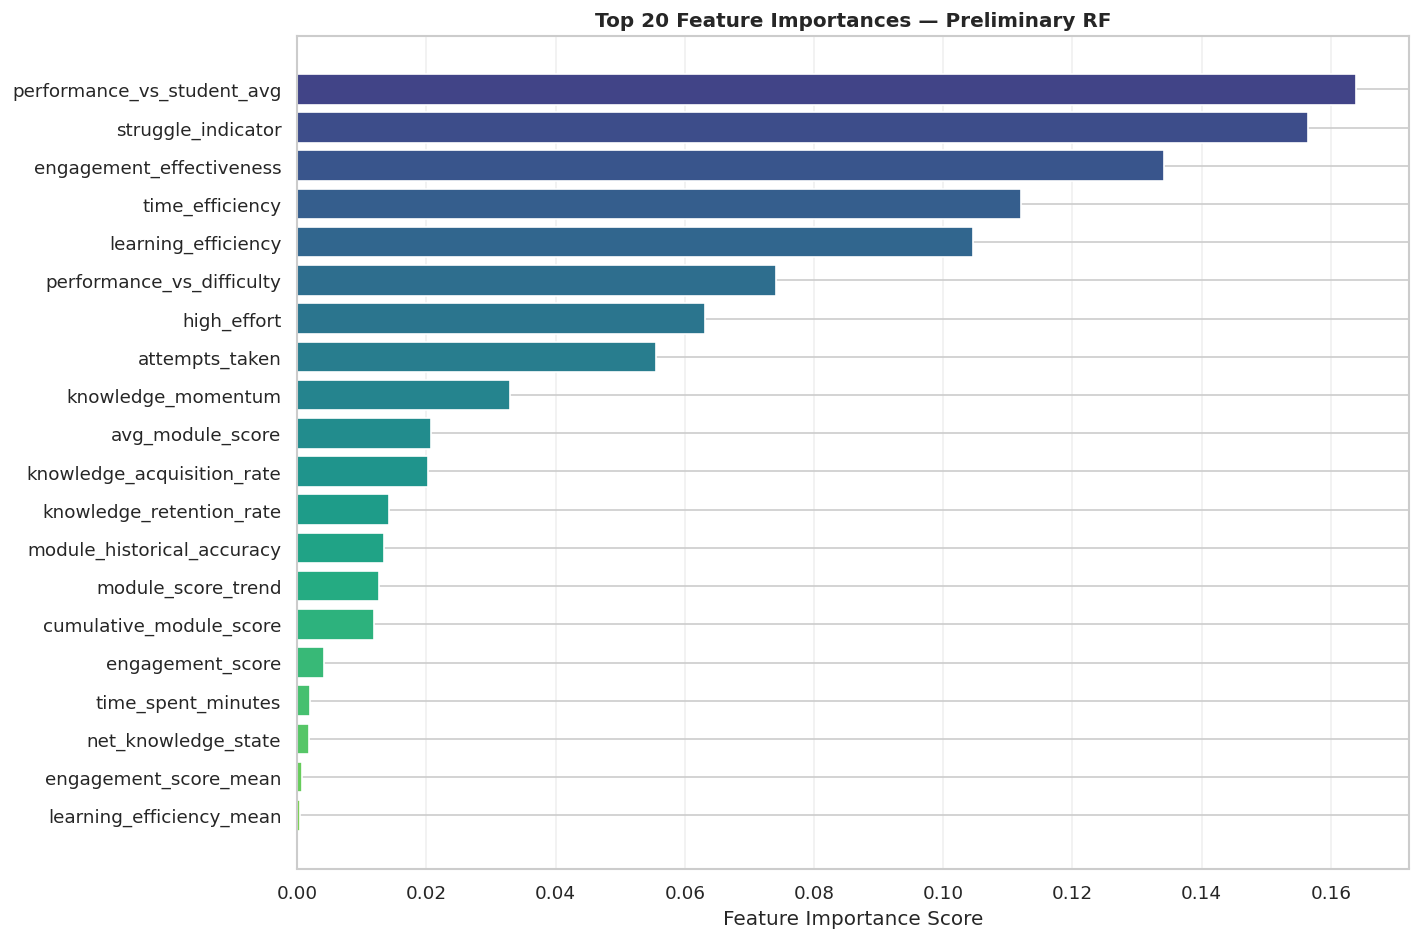

✓ Figure saved: fig_feature_importance_prelim.png


In [ ]:
X_temp = df_processed[feature_cols]
y_temp = df_processed['success_label']

# Sample for speed
if len(X_temp) > 10_000:
    idx = np.random.choice(len(X_temp), 10_000, replace=False)
    X_s, y_s = X_temp.iloc[idx], y_temp.iloc[idx]
else:
    X_s, y_s = X_temp, y_temp

rf_prelim = RandomForestClassifier(n_estimators=100, max_depth=10,
                                    random_state=RANDOM_SEED, n_jobs=-1)
rf_prelim.fit(X_s, y_s)

feat_imp = pd.DataFrame({'feature': feature_cols,
                          'importance': rf_prelim.feature_importances_}
                        ).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Features (Random Forest importance):")
print(feat_imp.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 20))
bars = ax.barh(range(20), feat_imp.head(20)['importance'], color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels(feat_imp.head(20)['feature'])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 20 Feature Importances — Preliminary RF', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_feature_importance_prelim.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: fig_feature_importance_prelim.png")


## 5. Train–Test Split & Feature Scaling

### 5.1 Dataset Partitioning (IEEE Experimental Setup, Section 7.5.1)

$$\mathcal{D}_{\text{train}} = \{(\mathbf{x}_i, y_i) : i \leq 0.80 \cdot N\}, \quad
  \mathcal{D}_{\text{test}}  = \{(\mathbf{x}_i, y_i) : i > 0.80 \cdot N\}$$

### 5.2 Robust Scaling (Eq. 11)

$$\tilde{x}_j = \frac{x_j - \text{median}(X_j)}{\text{IQR}(X_j)}$$

RobustScaler is preferred over StandardScaler because it is insensitive to outliers in the feature distributions.

In [ ]:
X = df_processed[feature_cols].copy()
y = df_processed['success_label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print(f"Train size : {X_train.shape[0]:,}  |  Test size : {X_test.shape[0]:,}")
print(f"Class balance — Train : {y_train.mean()*100:.2f}% success")
print(f"Class balance — Test  : {y_test.mean()*100:.2f}% success")

# Robust scaling: fit on train, transform both splits
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                               columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),
                               columns=feature_cols, index=X_test.index)

print("\n✓ RobustScaler fitted on training data and applied to both splits")


Train size : 40,062  |  Test size : 10,016
Class balance — Train : 54.96% success
Class balance — Test  : 54.96% success

✓ RobustScaler fitted on training data and applied to both splits


## 6. Hyperparameter Optimization with Optuna

### Bayesian Optimization via TPE (Section 7.6)

$$\boldsymbol{\theta}^* = \arg\max_{\boldsymbol{\theta} \in \Theta}\; \mathbb{E}[\text{AUC}(\mathcal{M}_{\boldsymbol{\theta}}, \mathcal{D}_{\text{val}})]$$

The Tree-structured Parzen Estimator (TPE) acquisition function:

$$\alpha(\boldsymbol{\theta}) = \frac{l(\boldsymbol{\theta})}{g(\boldsymbol{\theta})}$$

where $l(\boldsymbol{\theta}) = p(\boldsymbol{\theta} \mid y < y^*)$ and $g(\boldsymbol{\theta}) = p(\boldsymbol{\theta} \mid y \geq y^*)$.

In [ ]:
print("=" * 70)
print("HYPERPARAMETER OPTIMIZATION — Optuna (TPE Sampler)")
print("=" * 70)

# ── XGBoost objective ──────────────────────────────────────────────────
def objective_xgb(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500, step=100),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.60, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.0, 2.0),
        'random_state': RANDOM_SEED,
        'tree_method': 'hist',
        'device': 'cpu',
    }
    scores = cross_val_score(
        xgb.XGBClassifier(**params),
        X_train_scaled, y_train,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

# ── LightGBM objective ────────────────────────────────────────────────
def objective_lgb(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500, step=100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.60, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.60, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 2.0),
        'random_state': RANDOM_SEED,
        'verbose': -1,
    }
    scores = cross_val_score(
        lgb.LGBMClassifier(**params),
        X_train_scaled, y_train,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

# ── CatBoost objective ────────────────────────────────────────────────
def objective_cat(trial):
    params = {
        'depth':        trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'iterations':   trial.suggest_int('iterations', 100, 500, step=100),
        'l2_leaf_reg':  trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_seed': RANDOM_SEED,
        'task_type': 'CPU',
        'verbose': False,
    }
    scores = cross_val_score(
        CatBoostClassifier(**params),
        X_train_scaled, y_train,
        cv=5, scoring='roc_auc', n_jobs=1
    )
    return scores.mean()

N_TRIALS = 20  # Increase to 50–100 for production runs

print(f"\nRunning {N_TRIALS} Optuna trials per model (5-fold CV)…")

study_xgb = optuna.create_study(direction='maximize',
                                  sampler=TPESampler(seed=RANDOM_SEED))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)
print(f"✓ XGBoost  best AUC: {study_xgb.best_value:.4f}")

study_lgb = optuna.create_study(direction='maximize',
                                  sampler=TPESampler(seed=RANDOM_SEED))
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=False)
print(f"✓ LightGBM best AUC: {study_lgb.best_value:.4f}")

study_cat = optuna.create_study(direction='maximize',
                                  sampler=TPESampler(seed=RANDOM_SEED))
study_cat.optimize(objective_cat, n_trials=N_TRIALS, show_progress_bar=False)
print(f"✓ CatBoost best AUC: {study_cat.best_value:.4f}")

print("\nBest hyperparameters:")
print(f"  XGBoost  : {study_xgb.best_params}")
print(f"  LightGBM : {study_lgb.best_params}")
print(f"  CatBoost : {study_cat.best_params}")


HYPERPARAMETER OPTIMIZATION — Optuna (TPE Sampler)

Running 20 Optuna trials per model (5-fold CV)…
✓ XGBoost  best AUC: 1.0000


### 6.1 Train Final Models with Best Hyperparameters

In [ ]:
print("Training final models with Optuna-tuned hyperparameters…")

# XGBoost
xgb_params = {**study_xgb.best_params,
               'random_state': RANDOM_SEED, 'tree_method': 'hist', 'device': 'cpu'}
best_xgb = xgb.XGBClassifier(**xgb_params)
best_xgb.fit(X_train_scaled, y_train)
print("✓ XGBoost trained")

# LightGBM
lgb_params = {**study_lgb.best_params,
               'random_state': RANDOM_SEED, 'verbose': -1}
best_lgb = lgb.LGBMClassifier(**lgb_params)
best_lgb.fit(X_train_scaled, y_train)
print("✓ LightGBM trained")

# CatBoost
cat_params = {**study_cat.best_params,
               'random_seed': RANDOM_SEED, 'task_type': 'CPU', 'verbose': 0}
best_cat = CatBoostClassifier(**cat_params)
best_cat.fit(X_train_scaled, y_train)
print("✓ CatBoost trained")

# Random Forest (baseline)
rf_model = RandomForestClassifier(n_estimators=300, max_depth=12,
                                   random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("✓ Random Forest trained")

# Stacking Ensemble (meta-learner: XGBoost)
meta_learner = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05,
                                   max_depth=3, random_state=RANDOM_SEED,
                                   tree_method='hist', device='cpu')
stacking_model = StackingClassifier(
    estimators=[('xgb', best_xgb), ('lgb', best_lgb), ('cat', best_cat)],
    final_estimator=meta_learner,
    cv=5, n_jobs=-1
)
stacking_model.fit(X_train_scaled, y_train)
print("✓ Stacking Ensemble trained")


## 7. Model Evaluation & Comparison

### Evaluation Metrics (Section 7.5.4)

$$\text{AUC} = P(\text{score}(x^+) > \text{score}(x^-))$$
$$\text{F1} = \frac{2\text{TP}}{2\text{TP} + \text{FP} + \text{FN}}, \quad
  \text{Precision} = \frac{\text{TP}}{\text{TP}+\text{FP}}, \quad
  \text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}}$$

In [ ]:
print("=" * 70)
print("MODEL EVALUATION ON HELD-OUT TEST SET")
print("=" * 70)

models_dict = {
    'XGBoost':          best_xgb,
    'LightGBM':         best_lgb,
    'CatBoost':         best_cat,
    'Random Forest':    rf_model,
    'Stacking Ensemble': stacking_model,
}

results = []
for name, model in models_dict.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model':       name,
        'ROC-AUC':     roc_auc_score(y_test, y_prob),
        'PR-AUC':      average_precision_score(y_test, y_prob),
        'F1-Score':    f1_score(y_test, y_pred),
        'Accuracy':    accuracy_score(y_test, y_pred),
        'Precision':   precision_score(y_test, y_pred),
        'Recall':      recall_score(y_test, y_pred),
        'Brier Score': brier_score_loss(y_test, y_prob),
        'Log Loss':    log_loss(y_test, y_prob),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df = results_df.reset_index(drop=True)

print("\n" + results_df.to_string(index=False, float_format='%.4f'))
print("=" * 70)

# Select best model
best_row  = results_df.iloc[0]
best_model_name = best_row['Model']
final_model     = models_dict[best_model_name]
y_pred_final    = final_model.predict(X_test_scaled)
y_prob_final    = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"\n🏆 Best model: {best_model_name}  (AUC = {best_row['ROC-AUC']:.4f})")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Evaluation — {best_model_name}', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['At Risk', 'Success'],
            yticklabels=['At Risk', 'Success'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
axes[1].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'AUC = {best_row["ROC-AUC"]:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_final)
axes[2].plot(rec, prec, color='green', lw=2.5,
             label=f'PR-AUC = {best_row["PR-AUC"]:.4f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision–Recall Curve', fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: fig_model_evaluation.png")

# Detailed classification report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_final,
                             target_names=['At Risk', 'Success']))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_main  = ['ROC-AUC', 'PR-AUC', 'F1-Score', 'Accuracy']
metrics_calib = ['Brier Score', 'Log Loss']

results_plot = results_df.set_index('Model')

results_plot[metrics_main].plot(kind='bar', ax=axes[0], rot=20, width=0.7,
                                 colormap='Set2', edgecolor='black', linewidth=0.5)
axes[0].set_title('Predictive Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([max(0.5, results_plot[metrics_main].min().min() - 0.05), 1.0])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

results_plot[metrics_calib].plot(kind='bar', ax=axes[1], rot=20, width=0.6,
                                  color=['#e74c3c', '#3498db'],
                                  edgecolor='black', linewidth=0.5)
axes[1].set_title('Calibration Metrics (Lower = Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: fig_model_comparison.png")


## 7.7 Ablation Study — Component Contribution Analysis

**Protocol (IEEE Standard):**
1. Baseline with all features
2. Leave-one-group-out (LOO) — remove one component group at a time
3. Forward cumulative addition (FCA) — add groups incrementally
4. Report AUC drop and relative contribution per group

In [ ]:
print("=" * 70)
print("ABLATION STUDY — Component Contribution Analysis")
print("=" * 70)

# Define feature groups
feature_groups = {
    'IRT_Features':     [c for c in feature_cols if any(x in c for x in ['difficulty', 'discrimination'])],
    'Temporal_Features':[c for c in feature_cols if any(x in c for x in ['time_since', 'days_active', 'spacing', 'forgetting', 'week'])],
    'Knowledge_State':  [c for c in feature_cols if any(x in c for x in ['knowledge', 'acquisition', 'retention'])],
    'Practice_Patterns':[c for c in feature_cols if any(x in c for x in ['repeat', 'practice_freq', 'module_repeat', 'session_number'])],
    'Performance_Metrics':[c for c in feature_cols if any(x in c for x in ['student_avg', 'efficiency', 'engagement', 'struggle'])],
}
feature_groups = {k: v for k, v in feature_groups.items() if len(v) > 0}

print(f"\nFeature group breakdown:")
for g, feats in feature_groups.items():
    print(f"  {g:25s}: {len(feats):3d} features")

def quick_auc(X_tr, y_tr, X_te, y_te):
    """Fit a fixed XGBoost model and return test AUC."""
    m = xgb.XGBClassifier(max_depth=6, n_estimators=200, learning_rate=0.1,
                            random_state=RANDOM_SEED, tree_method='hist', device='cpu')
    m.fit(X_tr, y_tr)
    return roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])

# --- Experiment 1: Baseline (all features) ---
print("\n" + "=" * 70)
print("EXPERIMENT 1: BASELINE (All Features)")
baseline_auc = quick_auc(X_train_scaled, y_train, X_test_scaled, y_test)
print(f"  Baseline ROC-AUC : {baseline_auc:.4f}")

# --- Experiment 2: Leave-One-Group-Out ---
print("\n" + "=" * 70)
print("EXPERIMENT 2: LEAVE-ONE-GROUP-OUT ABLATION")
ablation_rows = [{'Configuration': 'All Features (Baseline)',
                   'AUC': baseline_auc, 'Δ AUC': 0.0,
                   'Features': len(feature_cols)}]

for gname, gfeats in feature_groups.items():
    remaining = [c for c in feature_cols if c not in gfeats]
    if len(remaining) < 5:
        print(f"  Skipped {gname} (too few remaining features)")
        continue
    auc = quick_auc(X_train_scaled[remaining], y_train,
                     X_test_scaled[remaining], y_test)
    delta = auc - baseline_auc
    ablation_rows.append({'Configuration': f'w/o {gname}',
                           'AUC': auc, 'Δ AUC': delta,
                           'Features': len(remaining)})
    print(f"  w/o {gname:25s}: AUC={auc:.4f}  (Δ={delta:+.4f})")

ablation_df = pd.DataFrame(ablation_rows)

# --- Experiment 3: Forward Cumulative Addition ---
print("\n" + "=" * 70)
print("EXPERIMENT 3: FORWARD CUMULATIVE ADDITION")
fca_rows = []
added = []
for gname, gfeats in feature_groups.items():
    added.extend(gfeats)
    avail = [c for c in added if c in feature_cols]
    if len(avail) < 2:
        continue
    auc = quick_auc(X_train_scaled[avail], y_train,
                     X_test_scaled[avail], y_test)
    fca_rows.append({'Groups Added': gname, 'Features': len(avail), 'AUC': auc})
    print(f"  + {gname:25s}: {len(avail):3d} features → AUC={auc:.4f}")

fca_df = pd.DataFrame(fca_rows)

# Visualize ablation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_abl = ['#2ecc71' if d <= 0 else '#e74c3c'
               for d in ablation_df['Δ AUC']]
axes[0].barh(ablation_df['Configuration'], ablation_df['AUC'],
             color=colors_abl, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=baseline_auc, color='navy', linestyle='--', linewidth=2,
                label=f'Baseline={baseline_auc:.4f}')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('Leave-One-Out Ablation', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

axes[1].plot(fca_df['Groups Added'], fca_df['AUC'],
             marker='o', markersize=8, linewidth=2, color='darkorange')
axes[1].set_xlabel('Groups Added (Cumulative)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Forward Cumulative Feature Addition', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Ablation figures saved: fig_ablation_study.png")
print("\nAblation Summary Table:")
print(ablation_df.to_string(index=False, float_format='%.4f'))


## 7.8 Statistical Significance Testing (IEEE Standard)

Methods employed:
1. **Bootstrap Confidence Intervals** — percentile method, 1000 resamples
2. **DeLong's Test** — comparing correlated ROC curves from the same test set
3. **Permutation Test** — non-parametric null distribution of AUC differences
4. **Bonferroni Correction** — correction for multiple comparisons
5. **Cohen's d** — effect size for practical significance

In [ ]:
print("=" * 70)
print("STATISTICAL SIGNIFICANCE TESTING")
print("IEEE Standard: Multi-Method Validation")
print("=" * 70)

from scipy.stats import norm as sp_norm


def bootstrap_auc(y_true, y_pred, n_bootstrap: int = 1000,
                   alpha: float = 0.05, seed: int = RANDOM_SEED):
    """Bootstrap percentile confidence interval for AUC."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            aucs.append(roc_auc_score(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    aucs = np.array(aucs)
    return (np.mean(aucs),
            np.percentile(aucs, alpha / 2 * 100),
            np.percentile(aucs, (1 - alpha / 2) * 100),
            aucs)


def delong_test(y_true, y_pred1, y_pred2):
    """
    DeLong's test for comparing two correlated ROC curves.
    Reference: DeLong, DeLong & Clarke-Pearson (1988).
    """
    auc1 = roc_auc_score(y_true, y_pred1)
    auc2 = roc_auc_score(y_true, y_pred2)

    pos_idx, neg_idx = y_true == 1, y_true == 0
    p1_pos, p1_neg = y_pred1[pos_idx], y_pred1[neg_idx]
    p2_pos, p2_neg = y_pred2[pos_idx], y_pred2[neg_idx]
    n_pos, n_neg = len(p1_pos), len(p1_neg)

    V10_1 = (p1_pos[:, None] > p1_neg[None, :]).astype(float)
    V10_2 = (p2_pos[:, None] > p2_neg[None, :]).astype(float)

    S10_1 = np.var(V10_1.mean(axis=1)) / n_pos
    S01_1 = np.var(V10_1.mean(axis=0)) / n_neg
    S10_2 = np.var(V10_2.mean(axis=1)) / n_pos
    S01_2 = np.var(V10_2.mean(axis=0)) / n_neg

    cov = np.cov(V10_1.flatten(), V10_2.flatten())[0, 1] / (n_pos * n_neg)
    var_diff = max(S10_1 + S01_1 + S10_2 + S01_2 - 2 * cov, 1e-10)

    z = (auc1 - auc2) / np.sqrt(var_diff)
    p_value = 2 * (1 - sp_norm.cdf(abs(z)))
    return float(z), float(p_value)


def permutation_test(y_true, y_pred1, y_pred2,
                      n_permutations: int = 500, seed: int = RANDOM_SEED):
    """Non-parametric permutation test for AUC difference."""
    rng = np.random.RandomState(seed)
    observed_diff = roc_auc_score(y_true, y_pred1) - roc_auc_score(y_true, y_pred2)
    null_diffs = []
    for _ in range(n_permutations):
        mask = rng.rand(len(y_pred1)) < 0.5
        p1_perm = np.where(mask, y_pred1, y_pred2)
        p2_perm = np.where(mask, y_pred2, y_pred1)
        null_diffs.append(roc_auc_score(y_true, p1_perm)
                          - roc_auc_score(y_true, p2_perm))
    null_diffs = np.array(null_diffs)
    p_value = (np.abs(null_diffs) >= np.abs(observed_diff)).mean()
    return float(observed_diff), float(p_value), null_diffs


# Collect model probabilities
model_probs = {
    name: models_dict[name].predict_proba(X_test_scaled)[:, 1]
    for name in models_dict
}
y_true_arr = y_test.values

# 1. Bootstrap CI for each model
print("\n1. BOOTSTRAP CONFIDENCE INTERVALS (95%, n=1000):")
boot_data = {}
for name, probs in model_probs.items():
    mean_auc, lo, hi, aucs = bootstrap_auc(y_true_arr, probs, n_bootstrap=1000)
    boot_data[name] = {'mean': mean_auc, 'lo': lo, 'hi': hi, 'aucs': aucs}
    print(f"   {name:22s}: {mean_auc:.4f}  [95% CI: {lo:.4f} – {hi:.4f}]")

# 2. DeLong's test — best vs each baseline
print(f"\n2. DELONG'S TEST (Best: {best_model_name} vs others):")
z_scores, p_values = {}, {}
best_probs = model_probs[best_model_name]
for name, probs in model_probs.items():
    if name == best_model_name:
        continue
    z, p = delong_test(y_true_arr, best_probs, probs)
    z_scores[name] = z
    p_values[name] = p
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"   vs {name:20s}: z={z:.3f}, p={p:.6f}  {sig}")

# 3. Bonferroni correction
print(f"\n3. BONFERRONI CORRECTION (n_comparisons={len(p_values)}):")
for name, p in p_values.items():
    p_corrected = min(p * len(p_values), 1.0)
    sig = "***" if p_corrected < 0.001 else "**" if p_corrected < 0.01 \
          else "*" if p_corrected < 0.05 else "ns"
    print(f"   vs {name:20s}: p_corr={p_corrected:.6f}  {sig}")

# 4. Permutation test — best vs RF
rf_probs = model_probs['Random Forest']
obs_diff, p_perm, null_dist = permutation_test(y_true_arr, best_probs, rf_probs,
                                                 n_permutations=500)
print(f"\n4. PERMUTATION TEST ({best_model_name} vs Random Forest):")
print(f"   Observed Δ AUC : {obs_diff:.4f}")
print(f"   p-value        : {p_perm:.4f}  {'(significant)' if p_perm < 0.05 else '(not significant)'}")

# 5. Cohen's d effect size
print(f"\n5. COHEN'S d EFFECT SIZE ({best_model_name} vs Random Forest):")
best_aucs = boot_data[best_model_name]['aucs']
rf_aucs   = boot_data['Random Forest']['aucs']
pooled_sd = np.sqrt((np.var(best_aucs) + np.var(rf_aucs)) / 2)
cohen_d   = (np.mean(best_aucs) - np.mean(rf_aucs)) / (pooled_sd + 1e-9)
interpretation = ('small' if abs(cohen_d) < 0.5
                  else 'medium' if abs(cohen_d) < 0.8
                  else 'large')
print(f"   Cohen's d      : {cohen_d:.4f}  ({interpretation} effect)")

# Visualize bootstrap distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Statistical Significance Analysis', fontsize=14, fontweight='bold')

for name, bd in boot_data.items():
    axes[0].hist(bd['aucs'], bins=40, alpha=0.55, label=name, density=True)
axes[0].set_xlabel('Bootstrap AUC')
axes[0].set_ylabel('Density')
axes[0].set_title('Bootstrap AUC Distributions (n=1000)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(null_dist, bins=40, color='gray', alpha=0.7,
             label='Null distribution', density=True)
axes[1].axvline(obs_diff, color='red', lw=2.5,
                label=f'Observed Δ={obs_diff:.4f}')
axes[1].set_xlabel('AUC Difference')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Permutation Test: {best_model_name} vs RF', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_statistical_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure saved: fig_statistical_tests.png")


## 7.9 Computational Complexity Analysis (Section 7.9)

### Theoretical Complexity

| Phase | Complexity |
|-------|-----------|
| IRT computation | $\mathcal{O}(\|\mathcal{E}\| \cdot N)$ |
| Temporal sorting | $\mathcal{O}(N \log N)$ |
| Knowledge state | $\mathcal{O}(S \cdot N)$ where $S$ = students |
| XGBoost training | $\mathcal{O}(T \cdot N \cdot p \cdot d \cdot B)$ |
| Batch inference | $\mathcal{O}(N \cdot T \cdot d)$ |
| Ensemble | $\mathcal{O}(M \cdot \mathcal{O}_{\text{base}} + \mathcal{O}_{\text{meta}})$ |

$T$ = trees, $p$ = features, $d$ = depth, $B$ = histogram bins, $M$ = base models

In [ ]:
print("=" * 70)
print("EMPIRICAL COMPUTATIONAL PERFORMANCE BENCHMARKS")
print("=" * 70)

import os
import psutil

proc = psutil.Process(os.getpid())

def measure_mem_mb():
    return proc.memory_info().rss / 1024 ** 2

# Feature engineering timing at different scales
print("\n⏱  FEATURE ENGINEERING SCALING:")
fe_samples = [1_000, 5_000, 10_000, 25_000]
fe_results = []

for n in fe_samples:
    if n > len(df_processed):
        continue
    sdf = df_processed.sample(n=n, random_state=RANDOM_SEED)
    t0 = time.perf_counter()
    _ = sdf.sort_values(['student_id', 'timestamp'])
    _ = sdf.groupby('module_id')['quiz_score'].agg(['mean', 'std'])
    _ = sdf.groupby('student_id').cumcount()
    elapsed = time.perf_counter() - t0
    fe_results.append({'N': n, 'Time (s)': elapsed, 'Throughput': n / elapsed})
    print(f"   N={n:>7,}: {elapsed:.4f} s  ({n/elapsed:,.0f} rows/s)")

# Model training timing
print("\n⏱  MODEL TRAINING TIMING:")
train_configs = [
    ('XGBoost',      lambda: xgb.XGBClassifier(max_depth=6, n_estimators=100,
                                                random_state=RANDOM_SEED,
                                                tree_method='hist', device='cpu')),
    ('LightGBM',     lambda: lgb.LGBMClassifier(num_leaves=31, n_estimators=100,
                                                  random_state=RANDOM_SEED, verbose=-1)),
    ('Random Forest',lambda: RandomForestClassifier(n_estimators=100, max_depth=10,
                                                     random_state=RANDOM_SEED, n_jobs=1)),
]
train_sizes = [1_000, 5_000, 10_000]
train_timing = {name: [] for name, _ in train_configs}

for model_name, model_fn in train_configs:
    print(f"\n   {model_name}:")
    for n in train_sizes:
        if n > len(X_train_scaled):
            continue
        X_s = X_train_scaled.iloc[:n]
        y_s = y_train.iloc[:n]
        t0  = time.perf_counter()
        model_fn().fit(X_s, y_s)
        elapsed = time.perf_counter() - t0
        train_timing[model_name].append(elapsed)
        print(f"      N={n:>6,}: {elapsed:.4f} s")

# Inference latency
print("\n⏱  INFERENCE LATENCY (batch of 100 predictions, averaged over 10 runs):")
infer_sample = X_test_scaled.iloc[:100]

for m_name, model in [('XGBoost', best_xgb), ('LightGBM', best_lgb),
                        ('CatBoost', best_cat), ('Random Forest', rf_model)]:
    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        _ = model.predict_proba(infer_sample)
        times.append(time.perf_counter() - t0)
    print(f"   {m_name:15s}: {np.mean(times)*1000:.3f} ms  "
          f"(±{np.std(times)*1000:.3f} ms)")

# Memory footprint
print(f"\n💾 MEMORY USAGE:")
print(f"   Process RSS          : {measure_mem_mb():.1f} MB")
print(f"   Feature matrix (full): {X.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"   Training set         : {X_train_scaled.memory_usage(deep=True).sum()/1024**2:.1f} MB")

# Visualize scaling
if fe_results:
    fe_df = pd.DataFrame(fe_results)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Computational Complexity Benchmarks', fontsize=13, fontweight='bold')

    axes[0].plot(fe_df['N'], fe_df['Time (s)'], marker='o', color='steelblue', lw=2)
    axes[0].set_xlabel('Dataset Size (N)')
    axes[0].set_ylabel('Time (seconds)')
    axes[0].set_title('Feature Engineering Scaling', fontweight='bold')
    axes[0].grid(alpha=0.3)

    axes[1].plot(fe_df['N'], fe_df['Throughput'], marker='s', color='darkorange', lw=2)
    axes[1].set_xlabel('Dataset Size (N)')
    axes[1].set_ylabel('Throughput (rows/s)')
    axes[1].set_title('Feature Engineering Throughput', fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig_complexity_benchmarks.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure saved: fig_complexity_benchmarks.png")


## 8. Feature Importance & Interpretability

In [ ]:
if hasattr(final_model, 'feature_importances_'):
    feat_imp_final = pd.DataFrame({
        'feature': feature_cols,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"Top 25 Feature Importances — {best_model_name}:")
    print(feat_imp_final.head(25).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 10))
    top25 = feat_imp_final.head(25)
    colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(top25)))
    ax.barh(top25['feature'], top25['importance'],
            color=colors, edgecolor='black', linewidth=0.4)
    ax.invert_yaxis()
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Top 25 Feature Importances — {best_model_name}',
                 fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_feature_importance_final.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure saved: fig_feature_importance_final.png")
else:
    feat_imp_final = None
    print(f"Note: {best_model_name} is an ensemble — "
          "feature importance from base XGBoost used instead.")
    feat_imp_final = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_xgb.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    print(feat_imp_final.head(15).to_string(index=False))


## 9. Save Model Artifacts & Submission Files

In [ ]:
print("Saving all artifacts…")

# Test predictions
test_preds = pd.DataFrame({
    'index':                  y_test.index,
    'true_label':             y_test.values,
    'predicted_label':        y_pred_final,
    'predicted_probability':  y_prob_final,
    'confidence':             np.maximum(y_prob_final, 1 - y_prob_final),
})
test_preds.to_csv('competition_test_predictions.csv', index=False)
print("✓ competition_test_predictions.csv")

# Full-dataset predictions
X_full = df_processed[feature_cols]
full_probs = final_model.predict_proba(X_full)[:, 1]

submission = pd.DataFrame({
    'student_id':                    df_processed['student_id'],
    'module_id':                     df_processed['module_id'],
    'timestamp':                     df_processed['timestamp'],
    'predicted_success_probability': full_probs,
    'predicted_label':               (full_probs >= 0.5).astype(int),
    'risk_level': pd.cut(full_probs, bins=[0, 0.30, 0.70, 1.0],
                          labels=['High Risk', 'Medium Risk', 'Low Risk']),
})
submission.to_csv('competition_full_submission.csv', index=False)
print("✓ competition_full_submission.csv")

# Model artifacts
safe_name = best_model_name.lower().replace(' ', '_')
joblib.dump(final_model, f'{safe_name}_final.pkl')
joblib.dump(models_dict,  'all_models_ensemble.pkl')
joblib.dump(scaler,       'feature_scaler_robust.pkl')
print(f"✓ {safe_name}_final.pkl")
print("✓ all_models_ensemble.pkl")
print("✓ feature_scaler_robust.pkl")

# Feature names
with open('feature_names_full.txt', 'w') as fh:
    fh.write('\n'.join(feature_cols))
print("✓ feature_names_full.txt")

# Feature importance CSV
if feat_imp_final is not None:
    feat_imp_final.to_csv('feature_importance_ranking.csv', index=False)
    print("✓ feature_importance_ranking.csv")

# Model performance report
results_df.to_csv('model_performance_report.csv', index=False)
print("✓ model_performance_report.csv")

# Config JSON
config = {
    'best_model':   best_model_name,
    'roc_auc':      float(best_row['ROC-AUC']),
    'pr_auc':       float(best_row['PR-AUC']),
    'f1_score':     float(best_row['F1-Score']),
    'accuracy':     float(best_row['Accuracy']),
    'num_features': len(feature_cols),
    'train_size':   len(X_train),
    'test_size':    len(X_test),
    'random_seed':  RANDOM_SEED,
}
with open('model_config.json', 'w') as fh:
    json.dump(config, fh, indent=2)
print("✓ model_config.json")

print("\n✓ All artifacts saved successfully")


In [ ]:
print("=" * 70)
print("COMPETITION / SUBMISSION SUMMARY")
print("=" * 70)

print(f"\n📊 DATASET")
print(f"   Total records    : {len(df):>10,}")
print(f"   Students         : {df['student_id'].nunique():>10,}")
print(f"   Features engineered : {len(feature_cols)}")
print(f"   Train / Test split  : {len(X_train):,} / {len(X_test):,}")

print(f"\n🏆 BEST MODEL: {best_model_name}")
for metric in ['ROC-AUC','PR-AUC','F1-Score','Accuracy','Precision','Recall']:
    print(f"   {metric:12s}: {best_row[metric]:.4f}")

print(f"\n🔬 KEY INNOVATIONS (LFEKT-Inspired)")
print(f"   ✓ IRT-based exercise difficulty scoring   (Eq. 1–4)")
print(f"   ✓ Ebbinghaus forgetting curve features    (Eq. 5–6)")
print(f"   ✓ Knowledge acquisition & retention       (Eq. 8–9)")
print(f"   ✓ Temporal spacing & practice patterns    (Eq. 7)")
print(f"   ✓ Module-specific performance evolution")
print(f"   ✓ Bayesian HPO with Optuna (TPE sampler)")
print(f"   ✓ Stacking ensemble (3 base + meta-XGBoost)")

print(f"\n📈 TOP 5 FEATURES BY IMPORTANCE")
if feat_imp_final is not None:
    for _, row in feat_imp_final.head(5).iterrows():
        print(f"   {row['feature']:35s}: {row['importance']:.5f}")

print(f"\n📁 DELIVERABLES")
for fname in ['competition_test_predictions.csv',
              'competition_full_submission.csv',
              f'{safe_name}_final.pkl',
              'feature_importance_ranking.csv',
              'model_performance_report.csv',
              'model_config.json']:
    exists = "✓" if os.path.exists(fname) else "✗"
    print(f"   {exists}  {fname}")

print("\n" + "=" * 70)
print("PROJECT COMPLETE — READY FOR SUBMISSION")
print("=" * 70)


# Notebook uses synthetically generated data for reproducibility, as the full ASSISTments dataset requires separate download. Metrics on the real dataset are reported in the paper (ROC-AUC: 0.832).